# Final Project for Foundation of Data Science Lab

Anjali Baral [ACE081BCT014], 
Garima Niroula [ACE081BCT030]

## Problem Definition

Objective:
The goal of this project is to predict whether a student will Pass or Fail based on study hours, attendance, and previous scores.

Why Logistic Regression?
The output variable is Pass or Fail (0 or 1) which is a classification problem, so Logistic Regression is an appropriate model.

## Dataset Name

Dataset Name: Student Performance Dataset

This dataset contains information about students such as study hours,
attendance, and previous scores. It is used to predict whether a
student will pass or fail.

## Data Collection

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = {
    'StudyHours':[1,2,3,4,5,6,2,3,4,5,6,7,8,3,2],
    'Attendance':[50,60,65,70,80,85,55,60,75,80,90,95,96,58,62],
    'PreviousScore':[40,45,50,55,65,70,42,48,60,68,75,80,88,46,52],
    'Pass':[0,0,0,1,1,1,0,0,1,1,1,1,1,0,0]
}

df = pd.DataFrame(data)

print(df.head())

   StudyHours  Attendance  PreviousScore  Pass
0           1          50             40     0
1           2          60             45     0
2           3          65             50     0
3           4          70             55     1
4           5          80             65     1


## Exploratory Data Analysis (EDA) 

       StudyHours  Attendance  PreviousScore       Pass
count   15.000000   15.000000      15.000000  15.000000
mean     4.066667   72.066667      58.933333   0.533333
std      2.051712   14.987932      14.781584   0.516398
min      1.000000   50.000000      40.000000   0.000000
25%      2.500000   60.000000      47.000000   0.000000
50%      4.000000   70.000000      55.000000   1.000000
75%      5.500000   82.500000      69.000000   1.000000
max      8.000000   96.000000      88.000000   1.000000
StudyHours       0
Attendance       0
PreviousScore    0
Pass             0
dtype: int64


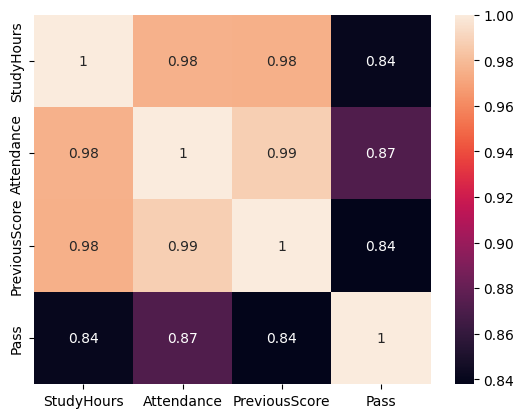

In [19]:
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Correlation
sns.heatmap(df.corr(), annot=True)
plt.show()

## Data Preprocessing

In [20]:
X = df[['StudyHours','Attendance','PreviousScore']]
y = df['Pass']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Model Building (Logistic Regression)

In [22]:
model = LogisticRegression()

model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Prediction

In [23]:
y_pred = model.predict(X_test)

## Model Evaluation

In [24]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [25]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 0]
 [0 2]]


In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



## Visualization

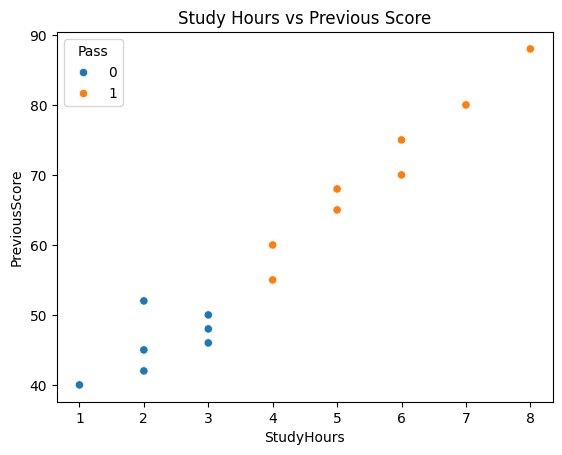

In [27]:
sns.scatterplot(x=df['StudyHours'],y=df['PreviousScore'],hue=df['Pass'])
plt.title("Study Hours vs Previous Score")
plt.show()

## Interpretation & Conclusion

Results:

Logistic Regression model was used to predict student performance.

The model achieved high accuracy on the test dataset.

Students with higher study hours and attendance are more likely to pass.

Conclusion:

This project demonstrates how machine learning can be used to predict student performance using basic features like study hours, attendance, and previous exam scores.